In [4]:
import pandas as pd 

data = pd.read_excel('../data/data_one.xlsx', header=1)
print(data.head())

   N Estado Civil   Grau de Instrução  N de Filhos  Salario (x Sal Min)  Anos  \
0  1     solteiro  ensino fundamental          NaN                 4.00    26   
1  2       casado  ensino fundamental          1.0                 4.56    32   
2  3       casado  ensino fundamental          2.0                 5.25    36   
3  4     solteiro        ensino médio          NaN                 5.73    20   
4  5     solteiro  ensino fundamental          NaN                 6.26    40   

   Meses Região de Procedência  
0      3              interior  
1     10               capital  
2      5               capital  
3     10                 outra  
4      7                 outra  


In [ ]:
classify_variables = {
    'Estado Civil': {
        'tipo': 'qualitativa nominal',
        'escala': 'nominal'
    },
    'Grau de Instrução': {
        'tipo': 'qualitativa ordinal', 
        'escala': 'ordinal'
    },
    'N de Filhos': {
        'tipo': 'quantitativa discreta',
        'escala': 'razão'
    },
    'Salario': {
        'tipo': 'quantitativa discreta',
        'escala': 'razão'
    },
    'Anos': {
        'tipo': 'quantitativa contínua',
        'escala': 'intervalar'
    },
    'Meses': {
        'tipo': 'quantitativa contínua',
        'escala': 'intervalar'
    },
    'Regiao': {
        'tipo': 'qualitativa nominal',
        'escala': 'nominal'
    }
}

Não existe nenhuma variável dicotômica, logo:

In [18]:
data = pd.DataFrame(data)

mask = data['Região de Procedência'] == 'capital'

data['É Capital?'] = mask
print(data.head())

   N Estado Civil   Grau de Instrução  N de Filhos  Salario (x Sal Min)  Anos  \
0  1     solteiro  ensino fundamental          NaN                 4.00    26   
1  2       casado  ensino fundamental          1.0                 4.56    32   
2  3       casado  ensino fundamental          2.0                 5.25    36   
3  4     solteiro        ensino médio          NaN                 5.73    20   
4  5     solteiro  ensino fundamental          NaN                 6.26    40   

   Meses Região de Procedência  É Capital?  
0      3              interior       False  
1     10               capital        True  
2      5               capital        True  
3     10                 outra       False  
4      7                 outra       False  


In [22]:
data['Grau de Instrução']
# frequencia absoluta 
fi = data['Grau de Instrução'].value_counts()

# frequencia relativa
ni = data['Grau de Instrução'].value_counts(normalize=True) * 100

tabela = pd.DataFrame({
    'Frequência Absoluta (f_i)': fi,
    'Frequência Relativa (%)': ni.round(1),
    'Frequência Acumulada': fi.cumsum()
})

print(tabela)

                    Frequência Absoluta (f_i)  Frequência Relativa (%)  \
Grau de Instrução                                                        
ensino médio                               18                     50.0   
ensino fundamental                         12                     33.3   
superior                                    6                     16.7   

                    Frequência Acumulada  
Grau de Instrução                         
ensino médio                          18  
ensino fundamental                    30  
superior                              36  


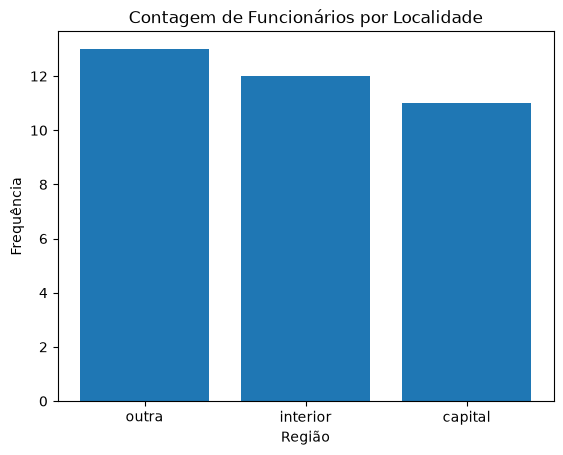

In [39]:
import matplotlib.pyplot as plt 

# ve a frequencia absoluta 
fi = data['Região de Procedência'].value_counts()

plt.bar(fi.index, fi.values)
plt.title('Contagem de Funcionários por Localidade')
plt.xlabel('Região')
plt.ylabel('Frequência')

plt.show()

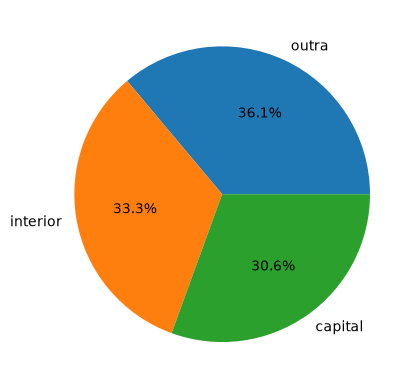

In [40]:
plt.pie(fi.values, labels=fi.index,  autopct='%1.1f%%')

Comparação:

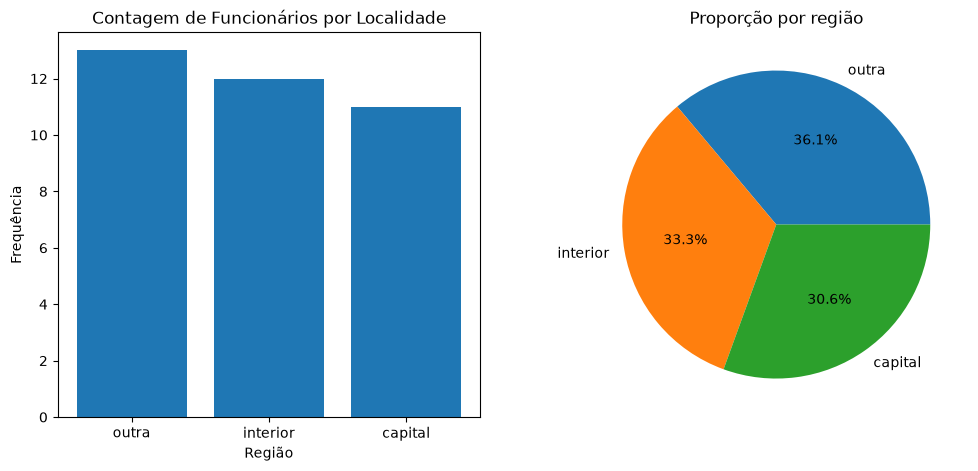

In [41]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.bar(fi.index, fi.values)
plt.title('Contagem de Funcionários por Localidade')
plt.xlabel('Região')
plt.ylabel('Frequência')

plt.subplot(1,2,2)
plt.pie(fi.values, labels=fi.index, autopct='%1.1f%%')
plt.title('Proporção por região')


plt.show()

In [ ]:
valores_faltantes = data['N de Filhos'].isna().sum()
print(valores_faltantes)

16


In [ ]:
mask_nan = data['N de Filhos'].isna()

comp = data.loc[mask_nan, 'Estado Civil']

0     solteiro
3     solteiro
4     solteiro
6     solteiro
7     solteiro
9     solteiro
11    solteiro
12    solteiro
15    solteiro
18    solteiro
19    solteiro
21    solteiro
22    solteiro
26    solteiro
30    solteiro
33    solteiro
Name: Estado Civil, dtype: str


In [58]:
data['Estado Civil- sem filhos'] = comp

print(data.head())

   N Estado Civil   Grau de Instrução  N de Filhos  Salario (x Sal Min)  Anos  \
0  1     solteiro  ensino fundamental          NaN                 4.00    26   
1  2       casado  ensino fundamental          1.0                 4.56    32   
2  3       casado  ensino fundamental          2.0                 5.25    36   
3  4     solteiro        ensino médio          NaN                 5.73    20   
4  5     solteiro  ensino fundamental          NaN                 6.26    40   

   Meses Região de Procedência Estado Civil- sem filhos  
0      3              interior                 solteiro  
1     10               capital                      NaN  
2      5               capital                      NaN  
3     10                 outra                 solteiro  
4      7                 outra                 solteiro  


In [65]:
import numpy as np 

quantidade_filhos = data['N de Filhos'].count()

total = len(data['N de Filhos'])

media_filhos = data['N de Filhos'].mean()

media_s_filhos = np.nanmean(data['N de Filhos'])

print(media_filhos)
print(media_s_filhos)


1.65
1.65


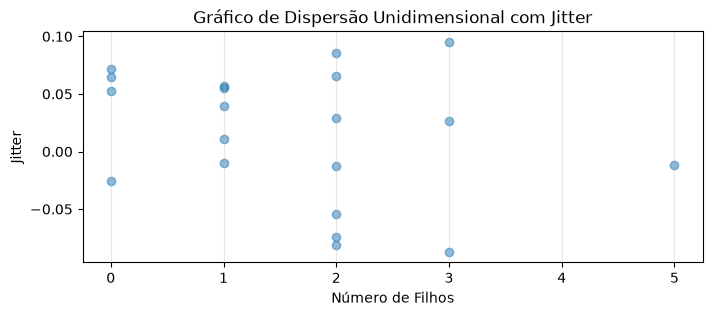

In [70]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(seed=42)

dados_filhos = data['N de Filhos'].dropna()

y_constante = np.zeros(len(dados_filhos))

jitter_y = y_constante + rng.uniform(-0.1, 0.1, size=len(dados_filhos))

plt.figure(figsize=(8, 3))
plt.scatter(dados_filhos, jitter_y, alpha=0.5)

plt.xlabel('Número de Filhos')
plt.ylabel('Jitter')
plt.title('Gráfico de Dispersão Unidimensional com Jitter')
plt.grid(axis='x', alpha=0.3)

plt.show()


  Faixa de Valores [a, b)  Frequência Absoluta (fi)
0            [4.00, 7.86)                        10
1           [7.86, 11.72)                        12
2          [11.72, 15.58)                         7
3          [15.58, 19.44)                         6
4          [19.44, 23.30)                         1


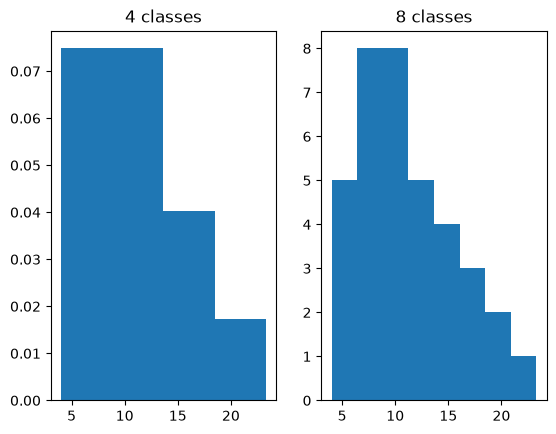

In [91]:
frequencias, bordas = np.histogram(data['Salario (x Sal Min)'], bins=5)

intervalos = [f"[{bordas[i]:.2f}, {bordas[i+1]:.2f})" for i in range(len(bordas)-1)]
tabela_frequencias = pd.DataFrame({
    'Faixa de Valores [a, b)': intervalos,
    'Frequência Absoluta (fi)': frequencias
})

print(tabela_frequencias)


plt.subplot(1,2,1)
plt.hist(data['Salario (x Sal Min)'], bins=4, density=True)
plt.title('4 classes')


plt.subplot(1,2,2)
plt.hist(data['Salario (x Sal Min)'], bins=8)
plt.title('8 classes')


plt.show()

Text(0.5, 1.0, 'Classes separadas pela regra Sturges')

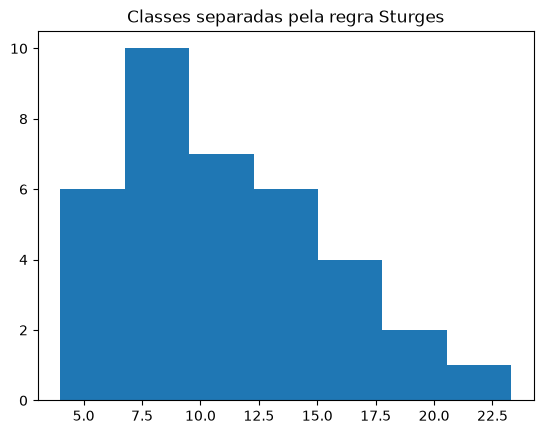

In [85]:
plt.hist(data['Salario (x Sal Min)'], bins='sturges')
plt.title('Classes separadas pela regra Sturges')